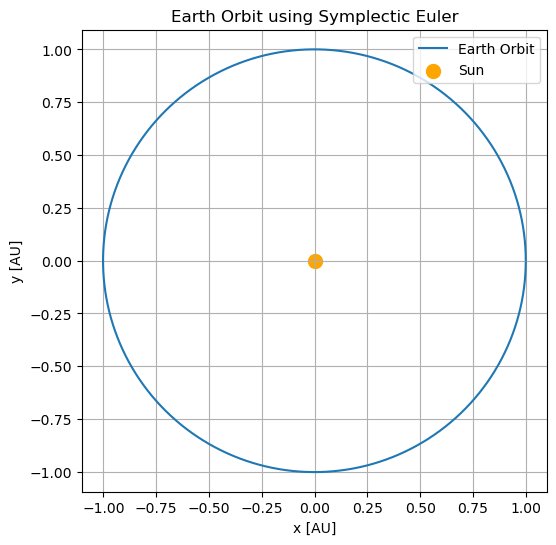

In [2]:
# Code
import numpy as np
import matplotlib.pyplot as plt

# Constants
G = 6.67430e-11  # gravitational constant (m^3 kg^-1 s^-2)
M_sun = 1.989e30  # mass of Sun (kg)
AU = 1.496e11  # astronomical unit (m)
year = 365 * 24 * 3600  # year in seconds

# Initial conditions
r0 = np.array([AU, 0.0])  # initial position (m)
v0 = np.array([0.0, 29.8e3])  # initial velocity (m/s)

# Simulation parameters
dt = 3600  # time step (1 hour in seconds)
steps = int(year / dt)

# Arrays to store positions
r = np.zeros((steps, 2))
v = np.zeros((steps, 2))

# Initialize
r[0] = r0
v[0] = v0

# Symplectic Euler integration
for i in range(steps - 1):
    # acceleration
    dist = np.linalg.norm(r[i])
    a = -G * M_sun * r[i] / dist**3

    # Update v
    v[i + 1] = v[i] + a * dt

    # Update r
    r[i + 1] = r[i] + v[i + 1] * dt

# Plot orbit
plt.figure(figsize=(6, 6))
plt.plot(r[:, 0] / AU, r[:, 1] / AU, label="Earth Orbit")
plt.scatter(0, 0, color='orange', s=100, label="Sun")
plt.xlabel("x [AU]")
plt.ylabel("y [AU]")
plt.title("Earth Orbit using Symplectic Euler")
plt.legend(loc='upper right')
plt.grid(True)
plt.axis('equal')
plt.show()

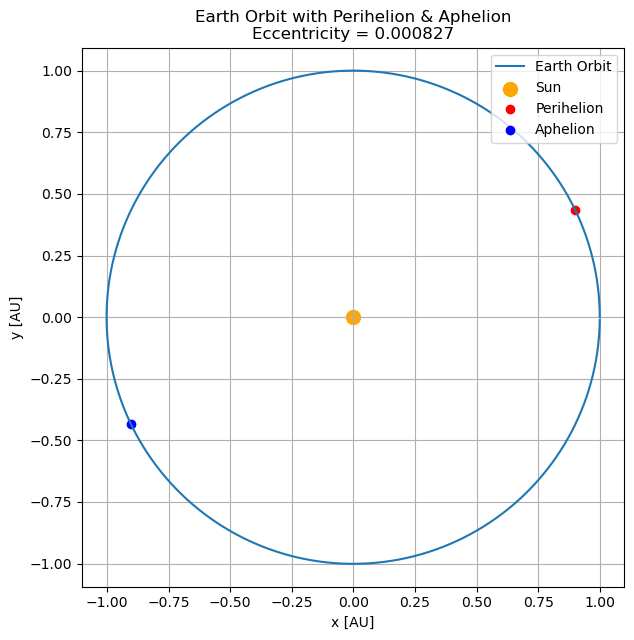

Perihelion distance: 0.999918 AU
Aphelion distance: 1.001574 AU
Eccentricity: 0.000827


In [3]:
# Code
import numpy as np
import matplotlib.pyplot as plt

# Constants
G = 6.67430e-11  # gravitational constant (m^3 kg^-1 s^-2)
M_sun = 1.989e30  # mass of the Sun (kg)
AU = 1.496e11  # astronomical unit (m)
year = 365 * 24 * 3600  # year in (s)

# Initial conditions
r0 = np.array([AU, 0.0])  # initial position (m)
v0 = np.array([0.0, 29.8e3])  # initial velocity (m/s)

# Simulation parameters
dt = 3600  # time step (1 hour)
steps = int(year / dt)

# Arrays to store positions
r = np.zeros((steps, 2))
v = np.zeros((steps, 2))

# Initialize
r[0] = r0
v[0] = v0

# Symplectic Euler integration
for i in range(steps - 1):
    dist = np.linalg.norm(r[i])
    a = -G * M_sun * r[i] / dist**3
    v[i + 1] = v[i] + a * dt
    r[i + 1] = r[i] + v[i + 1] * dt

# perihelion and aphelion
distances = np.linalg.norm(r, axis=1)
r_p = np.min(distances)  # perihelion
r_a = np.max(distances)  # aphelion

# eccentricity
eccentricity = (r_a - r_p) / (r_a + r_p)

# indices for perihelion and aphelion
idx_p = np.argmin(distances)
idx_a = np.argmax(distances)

# Plot orbit with perihelion and aphelion marked
plt.figure(figsize=(7, 7))
plt.plot(r[:, 0] / AU, r[:, 1] / AU, label="Earth Orbit")
plt.scatter(0, 0, color='orange', s=100, label="Sun")
plt.scatter(r[idx_p, 0] / AU, r[idx_p, 1] / AU, color='red', label="Perihelion")
plt.scatter(r[idx_a, 0] / AU, r[idx_a, 1] / AU, color='blue', label="Aphelion")
plt.xlabel("x [AU]")
plt.ylabel("y [AU]")
plt.title(f"Earth Orbit with Perihelion & Aphelion\nEccentricity = {eccentricity:.6f}")
plt.legend(loc='upper right')
plt.grid(True)
plt.axis('equal')
plt.show()

# Print results
print(f"Perihelion distance: {r_p / AU:.6f} AU")
print(f"Aphelion distance: {r_a / AU:.6f} AU")
print(f"Eccentricity: {eccentricity:.6f}")

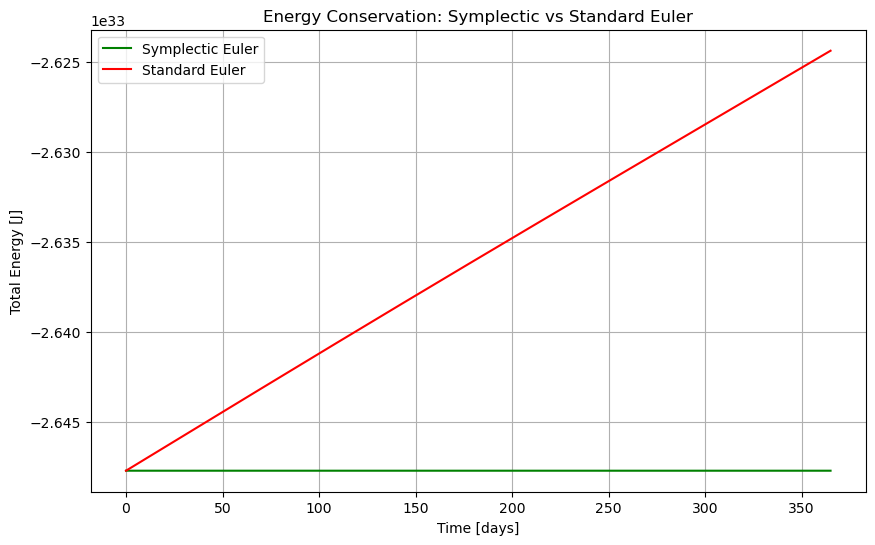

Symplectic Euler: Energy variation = 0.0001%
Standard Euler: Energy variation = 0.8823%


In [4]:
# Code
import numpy as np
import matplotlib.pyplot as plt

# Constants
G = 6.67430e-11  # gravitational constant (m^3 kg^-1 s^-2)
M_sun = 1.989e30  # mass of the Sun (kg)
AU = 1.496e11  # astronomical unit (m)
m_earth = 5.972e24  # mass of Earth (kg)
year = 365 * 24 * 3600  # one year (s)

# Initial conditions
r0 = np.array([AU, 0.0])  # initial position (m)
v0 = np.array([0.0, 29.8e3])  # initial velocity (m/s)

# Simulation parameters
dt = 3600  # time step (1 hour)
steps = int(year / dt)

# Functions
def acceleration(r):
    dist = np.linalg.norm(r)
    return -G * M_sun * r / dist**3

def total_energy(r, v):
    dist = np.linalg.norm(r)
    kinetic = 0.5 * m_earth * np.dot(v, v)
    potential = -G * M_sun * m_earth / dist
    return kinetic + potential

# Symplectic Euler
r_sym = np.zeros((steps, 2))
v_sym = np.zeros((steps, 2))
energy_sym = np.zeros(steps)

r_sym[0] = r0
v_sym[0] = v0
energy_sym[0] = total_energy(r0, v0)

for i in range(steps - 1):
    a = acceleration(r_sym[i])
    v_sym[i + 1] = v_sym[i] + a * dt
    r_sym[i + 1] = r_sym[i] + v_sym[i + 1] * dt
    energy_sym[i + 1] = total_energy(r_sym[i + 1], v_sym[i + 1])

# Standard Euler
r_euler = np.zeros((steps, 2))
v_euler = np.zeros((steps, 2))
energy_euler = np.zeros(steps)

r_euler[0] = r0
v_euler[0] = v0
energy_euler[0] = total_energy(r0, v0)

for i in range(steps - 1):
    a = acceleration(r_euler[i])
    r_euler[i + 1] = r_euler[i] + v_euler[i] * dt
    v_euler[i + 1] = v_euler[i] + a * dt
    energy_euler[i + 1] = total_energy(r_euler[i + 1], v_euler[i + 1])

# Time array
time_days = np.arange(steps) * dt / (24 * 3600)

# Plot energy comparison
plt.figure(figsize=(10, 6))
plt.plot(time_days, energy_sym, label="Symplectic Euler", color='green')
plt.plot(time_days, energy_euler, label="Standard Euler", color='red')
plt.xlabel("Time [days]")
plt.ylabel("Total Energy [J]")
plt.title("Energy Conservation: Symplectic vs Standard Euler")
plt.legend()
plt.grid(True)
plt.show()

# Print energy variation summary
print(f"Symplectic Euler: Energy variation = {((max(energy_sym)-min(energy_sym))/abs(energy_sym[0]))*100:.4f}%")
print(f"Standard Euler: Energy variation = {((max(energy_euler)-min(energy_euler))/abs(energy_euler[0]))*100:.4f}%")

### 4. Vary the energy of the orbit by changing initial value of speed.
Vary the total energy of the orbit by changing the magnitude, but not the direction, of $\mathbf{v_0}$, in a certain range $(0, v_{max})$. Plot the resulting orbits. __Hint 1__: To decide a meaningful range of values for $|\mathbf{v_0}|$, notice that we can get 3 qualitative different types of orbits (elliptic, parabolic, hyperbolic). __Hint 2__: One can calculate the escape speed $v_e$ of an earth-like planet from the sun's gravitational well by equating $T+V=0$. __Hint 3__: if the initial speed $|\mathbf{v_0}|$ of the earth is not high enough, the earth might crash into the sun. You might need to decrease your time step $dt$ to simulate this case and introduce a stop criterion for the orbit. 

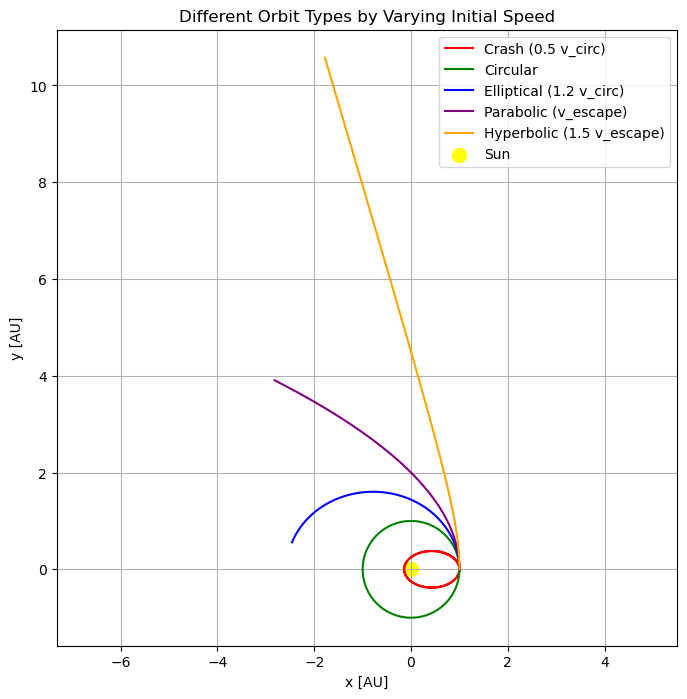

Circular speed: 29.79 km/s
Escape speed: 42.13 km/s


In [5]:
# Code
import numpy as np
import matplotlib.pyplot as plt

# Constants
G = 6.67430e-11  # gravitational constant (m^3 kg^-1 s^-2)
M_sun = 1.989e30  # mass of the Sun (kg)
AU = 1.496e11  # astronomical unit (m)
year = 365 * 24 * 3600  # year in (s)

# Initial position
r0 = np.array([AU, 0.0])

# Circular and escape speeds
v_circular = np.sqrt(G * M_sun / AU)
v_escape = np.sqrt(2 * G * M_sun / AU)

# Simulation parameters
dt = 3600  # 1 hour
steps = int(year / dt)

# Acceleration function
def acceleration(r):
    dist = np.linalg.norm(r)
    return -G * M_sun * r / dist**3

# Orbit simulation
def simulate_orbit(v_initial):
    r = np.zeros((steps, 2))
    v = np.zeros((steps, 2))
    r[0] = r0
    v[0] = np.array([0.0, v_initial])
    for i in range(steps - 1):
        a = acceleration(r[i])
        v[i + 1] = v[i] + a * dt
        r[i + 1] = r[i] + v[i + 1] * dt
        if np.linalg.norm(r[i + 1]) < 0.01 * AU:  # crash condition
            r = r[:i + 2]
            break
    return r

# Test
speeds = [0.5 * v_circular, v_circular, 1.2 * v_circular, v_escape, 1.5 * v_escape]
labels = ["Crash (0.5 v_circ)", "Circular", "Elliptical (1.2 v_circ)", "Parabolic (v_escape)", "Hyperbolic (1.5 v_escape)"]
colors = ['red', 'green', 'blue', 'purple', 'orange']

# Plot
plt.figure(figsize=(8, 8))
for speed, label, color in zip(speeds, labels, colors):
    orbit = simulate_orbit(speed)
    plt.plot(orbit[:, 0] / AU, orbit[:, 1] / AU, color=color, label=label)

plt.scatter(0, 0, color='yellow', s=100, label='Sun')
plt.xlabel("x [AU]")
plt.ylabel("y [AU]")
plt.title("Different Orbit Types by Varying Initial Speed")
plt.legend(loc='upper right')
plt.grid(True)
plt.axis('equal')
plt.show()

# Summary
print(f"Circular speed: {v_circular/1000:.2f} km/s")
print(f"Escape speed: {v_escape/1000:.2f} km/s")

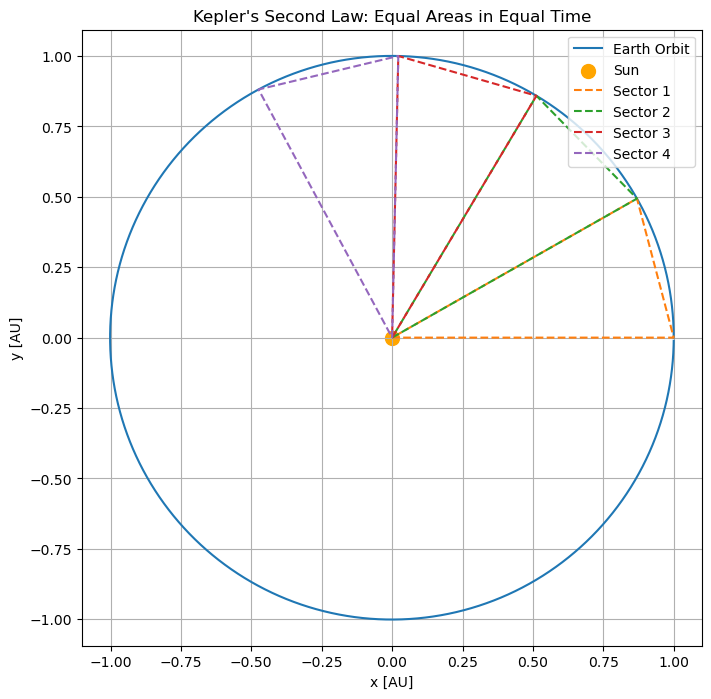

Areas swept in 30-day intervals (first 6):
Interval 1: 5.525e+21 m^2
Interval 2: 5.525e+21 m^2
Interval 3: 5.525e+21 m^2
Interval 4: 5.525e+21 m^2
Interval 5: 5.525e+21 m^2
Interval 6: 5.526e+21 m^2
Max area: 5.526e+21, Min area: 5.525e+21, Variation: 0.0217%


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
G = 6.67430e-11 # gravitational constant (m^3 kg^-1 s^-2)
M_sun = 1.989e30 # mass of the Sun (kg)
AU = 1.496e11 # astronomical unit (m)
year = 365 * 24 * 3600 # year in (s)

# Initial conditions
r0 = np.array([AU, 0.0])
v0 = np.array([0.0, 29.8e3])

# Simulation parameters
dt = 3600
steps = int(year / dt)

# Acceleration function
def acceleration(r):
    dist = np.linalg.norm(r)
    return -G * M_sun * r / dist**3

# Symplectic Euler integration
r = np.zeros((steps, 2))
v = np.zeros((steps, 2))
r[0] = r0
v[0] = v0

for i in range(steps - 1):
    a = acceleration(r[i])
    v[i + 1] = v[i] + a * dt
    r[i + 1] = r[i] + v[i + 1] * dt

# Check Kepler's second law
interval = 30 * 24 * 3600  # 30 days
interval_steps = int(interval / dt)
areas = []
sectors = []

for start in range(0, steps - interval_steps, interval_steps):
    p1 = r[start]
    p2 = r[start + interval_steps]
    area = 0.5 * abs(p1[0]*p2[1] - p1[1]*p2[0])  # triangle area
    areas.append(area)
    sectors.append((p1, p2))

# Plot orbit and sectors
plt.figure(figsize=(8, 8))
plt.plot(r[:, 0] / AU, r[:, 1] / AU, label="Earth Orbit")
plt.scatter(0, 0, color='orange', s=100, label="Sun")

for i, (p1, p2) in enumerate(sectors[:4]):
    plt.plot([0, p1[0] / AU, p2[0] / AU, 0], [0, p1[1] / AU, p2[1] / AU, 0], '--', label=f"Sector {i+1}")

plt.xlabel("x [AU]")
plt.ylabel("y [AU]")
plt.title("Kepler's Second Law: Equal Areas in Equal Time")
plt.legend(loc='upper right')
plt.grid(True)
plt.axis('equal')
plt.show()

# Print area values
print("Areas swept in 30-day intervals (first 6):")
for i, area in enumerate(areas[:6]):
    print(f"Interval {i+1}: {area:.3e} m^2")

print(f"Max area: {max(areas):.3e}, Min area: {min(areas):.3e}, Variation: {(max(areas)-min(areas))/max(areas)*100:.4f}%")

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# Orbital parameters
a = 1.0 # semimajor axis
e = 0.0167 # eccentricity
T = 365.25 # orbit period
omega = 2 * np.pi / T

def solve_kepler(M, e, tol=1e-12, maxiter=100):
    M = np.mod(M, 2*np.pi)
    if M > np.pi:
        M -= 2*np.pi
    E = M + e * np.sin(M)
    for _ in range(maxiter):
        f = E - e * np.sin(E) - M
        fp = 1 - e * np.cos(E)
        dE = -f / fp
        E += dE
        if np.abs(dE) < tol:
            break
    return E

def orbit_positions(times):
    M = omega * times
    E = np.array([solve_kepler(Mi, e) for Mi in M])
    cosf = (np.cos(E) - e) / (1 - e * np.cos(E))
    sinf = (np.sqrt(1 - e**2) * np.sin(E)) / (1 - e * np.cos(E))
    f = np.arctan2(sinf, cosf)
    r = a * (1 - e**2) / (1 + e * np.cos(f))
    x = r * np.cos(f)
    y = r * np.sin(f)
    return x, y

# smaller for speed / size
frames = 180
times = np.linspace(0, T, frames)
x, y = orbit_positions(times)

fig, ax = plt.subplots(figsize=(5,5))
ax.set_aspect('equal', 'box')
lim = 1.1 * (1 + e)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.set_title("Earth's orbit around the Sun (1 year)")

# Orbit path 
ax.plot(x.tolist(), y.tolist(), linewidth=0.8)

# Sun at focus: pass sequences
focus_x = -a * e
ax.plot([focus_x], [0], marker='o', markersize=10)

# Dynamic elements
earth_marker, = ax.plot([], [], marker='o', markersize=6, linestyle='') 
trail_line, = ax.plot([], [], linewidth=1, alpha=0.7)
day_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=9, verticalalignment='top')

def init():
    earth_marker.set_data([], [])
    trail_line.set_data([], [])
    day_text.set_text('')
    return earth_marker, trail_line, day_text

def animate(i):
    xi, yi = float(x[i]), float(y[i])   
    earth_marker.set_data([xi], [yi])

    start = max(0, i - 40)
    xs = x[start:i+1].tolist() if i >= start else []
    ys = y[start:i+1].tolist() if i >= start else []
    trail_line.set_data(xs, ys)

    day_text.set_text(f"Day: {times[i]:.1f} / {T:.1f}")
    return earth_marker, trail_line, day_text

anim = animation.FuncAnimation(
    fig, animate, init_func=init,
    frames=frames, interval=40, blit=True
)

plt.close(fig)
display(HTML(anim.to_jshtml()))

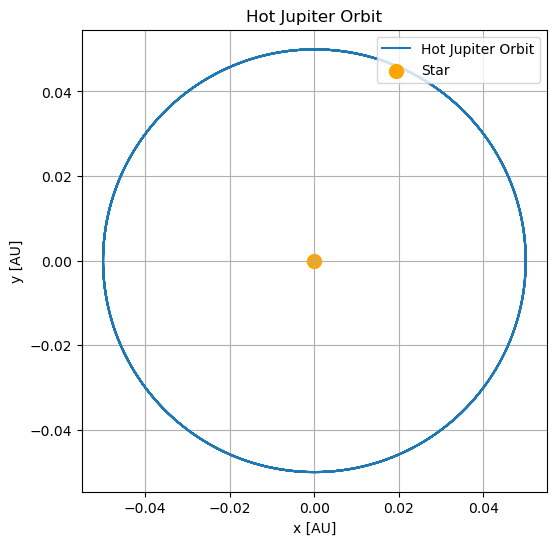

Initial circular speed: 133.22 km/s
Time step: 100 s, Total steps: 17280


In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
G = 6.67430e-11
M_star = 1.989e30  # Sun-like star
AU = 1.496e11
m_planet = 1.898e27  # Jupiter mass

# Hot Jupiter parameters
a = 0.05 * AU  # semi-major axis (m)
r0 = np.array([a, 0.0])
v_circular = np.sqrt(G * M_star / a)
v0 = np.array([0.0, v_circular])

# Simulation parameters
dt = 100  # time step in seconds
simulation_time = 20 * 24 * 3600  # 20 days
steps = int(simulation_time / dt)

# Acceleration function
def acceleration(r):
    dist = np.linalg.norm(r)
    return -G * M_star * r / dist**3

# Symplectic Euler integration
r = np.zeros((steps, 2))
v = np.zeros((steps, 2))
r[0] = r0
v[0] = v0

for i in range(steps - 1):
    a_vec = acceleration(r[i])
    v[i + 1] = v[i] + a_vec * dt
    r[i + 1] = r[i] + v[i + 1] * dt

# Plot orbit
plt.figure(figsize=(6, 6))
plt.plot(r[:, 0] / AU, r[:, 1] / AU, label="Hot Jupiter Orbit")
plt.scatter(0, 0, color='orange', s=100, label="Star")
plt.xlabel("x [AU]")
plt.ylabel("y [AU]")
plt.title("Hot Jupiter Orbit")
plt.legend(loc='upper right')
plt.grid(True)
plt.axis('equal')
plt.show()

# Print orbital speed and time step info
print(f"Initial circular speed: {v_circular/1000:.2f} km/s")
print(f"Time step: {dt} s, Total steps: {steps}")